In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

In [3]:
# Function to generate data
def get_sample(N,p):
    np.random.seed(1000)
    diag = np.ones(p)
    diag[0] = 8;diag[1] = 4;diag[2] = 4;diag[3] = 2
    cov = np.diag(diag)
    sample = np.dot(np.random.randn(N,p),cov)
    sample_all = np.concatenate((np.ones([N,1]),sample),axis=1)
    coff = np.random.randn(p+1)
    coff = 3*coff / (((coff**2).sum())**0.5)
    y = np.zeros(N)
    y[sigmoid(np.dot(sample_all,coff))>1-np.random.rand(N)] = 1
    return sample_all,coff,y

In [4]:
def sigmoid(x):
    x[x>0] = 1/(1+np.exp(-x[x>0]))
    x[x<0] = np.exp(x[x<0])/(1+np.exp(x[x<0]))
    return x

def sq_loss(y,x,b):
    return (y-np.dot(x,b)).sum()/n

def sq_backward(x,y,B_hat):
    y_hat = np.dot(x,B_hat)
    return 2*np.dot(y_hat-y,x)/n

def cross_entropy_loss(y,x,b):
    y_hat = sigmoid(np.dot(x,b))
    return -(y*np.log(y_hat)+(1-y)*np.log(1-y_hat)).sum()/len(y)

def cross_entropy_backward(x,y,B_hat):
    y_hat = sigmoid(np.dot(x,B_hat))
    return np.dot((y_hat-y),x)/len(y)

def accurate(x,y,b):
    y_hat = np.dot(x,b)
    y_hat[y_hat>0] = 1
    y_hat[y_hat<0] = 0
    return (y_hat == y).sum()/len(y)

def init(isgood,x_test,y_test,t,u,a,backward,X1,Y1,max_iter):
    w = np.zeros(p+1)
    if isgood:
        w = sub_grad(w,t,u,0,0,backward,X1,Y1,3000)

    error = [(((w - coffs)**2).sum())**0.5]
    accu= [1-accurate(x_test,y_test,w)]
    return w,error,accu

def mean(workgrad):
    return workgrad.mean(0)

def median(workgrad,m):
    return np.median(workgrad,0)

def trimean(workgrad,tri_a,m):
    cut_num = int(tri_a*m)
    return np.array([np.sort(para)[cut_num:m-cut_num].mean() for para in workgrad.transpose()])

def shrink(z, t):
    x = np.zeros(z.shape)
    x[z>t] = z[z>t]-t
    x[z<-t] = z[z<-t]+t
    return x

# optima
def sub_grad(w,t,u,a,wg,backward,X0,Y0,max_iter):
    w0 = w
    for i in range(max_iter):
        num_batch = len(X0) // 30
        j = i % num_batch
        x_batch = X0[30*j:30*(j+1)]
        y_batch = Y0[30*j:30*(j+1)]
        z = w-t*(backward(x_batch,y_batch,w) + wg + a*(w - w0))
        w = shrink(z,t*u)
    return w

In [5]:
def CEBRL(x_train,y_train,x_test,y_test,m,n,attr_num,t,u,a,bt_num,isgood,
          avg_func=mean,tri_a=None,max_iter=2000):
    
    ## t: step size;  u: lasso coefficient;  a: asymptotic term coefficient; bt_num: number of Byzantine workers;
    ## isgood: whether to use a good initial value; avg_func: average method;
    ## m: number of workers; n: data volume of each working machine
    
    data_x = x_train.reshape(m,n,attr_num+1)
    data_y = y_train.reshape(m,n)
    for epo in range(commu-1):
        if epo == 0:
            w,error,predict_error = init(isgood,x_test,y_test,t,u,a,backward,data_x[0],data_y[0],max_iter)
        workgrad = np.zeros([m,attr_num+1])
        for work in range(m):
            if work >= m-bt_num:
                workgrad[work] = -3*backward(data_x[work],data_y[work],w)
            else:
                workgrad[work] = backward(data_x[work],data_y[work],w)
            if work == 0:
                wg = 0-workgrad[work]
        if avg_func == trimean:
            wg += avg_func(workgrad,tri_a,m)
        elif avg_func == median:
            wg += avg_func(workgrad,m)
        else:
            wg += avg_func(workgrad)
        w = sub_grad(w,t,u,a,wg,backward,data_x[0],data_y[0],max_iter)
        error.append((((w - coffs)**2).sum())**0.5)
        predict_error.append(1-accurate(x_test,y_test,w))
        
    return w,error,predict_error

In [6]:
def init_name(isgood):
    if isgood:
        return 'goodinit'
    else:
        return '0init'
def norm_name(u):
    if u == 0:
        return 'no-norm'
    else:
        return 'add-norm'

In [7]:
def once_run(i,m,n,bt_num,a):
    sample_x,y = total_x[i*(N+test_num):(i+1)*(N+test_num)],total_y[i*(N+test_num):(i+1)*(N+test_num)]
    x_train_sample = sample_x[:N]
    y_train_sample = y[:N]
    x_test_sample = sample_x[N:]
    y_test_sample = y[N:]
    w = {};error = {};predict_error = {};
    w[0],error[0],predict_error[0]= CEBRL(x_train_sample,y_train_sample,x_test_sample,y_test_sample,
                                    m,n,p,t,u,a,0,isgood,avg_func=mean,max_iter=iter_num)
    w[1],error[1],predict_error[1]= CEBRL(x_train_sample,y_train_sample,x_test_sample,y_test_sample,
                                    m,n,p,t,u,a,bt_num,isgood,avg_func=mean,max_iter=iter_num)
    w[2],error[2],predict_error[2]= CEBRL(x_train_sample,y_train_sample,x_test_sample,y_test_sample,
                                    m,n,p,t,u,a,bt_num,isgood,avg_func=trimean,tri_a=0.2,max_iter=iter_num)
    w[3],error[3],predict_error[3]= CEBRL(x_train_sample,y_train_sample,x_test_sample,y_test_sample,
                                    m,n,p,t,u,a,bt_num,isgood,avg_func=median,max_iter=iter_num)
    w[4],error[4],predict_error[4]= CEBRL(x_train_sample,y_train_sample,x_test_sample,y_test_sample,
                                    m,n,p,t,u,0,bt_num,isgood,avg_func=trimean,tri_a=0.2,max_iter=iter_num)
    w[5],error[5],predict_error[5]= CEBRL(x_train_sample,y_train_sample,x_test_sample,y_test_sample,
                                    m,n,p,t,u,0,bt_num,isgood,avg_func=median,max_iter=iter_num)
    w[6],error[6],predict_error[6]= CEBRL(x_train_sample,y_train_sample,x_test_sample,y_test_sample,
                                    m,n,p,t,u,0,0,isgood,avg_func=mean,max_iter=iter_num)
    w[7],error[7],predict_error[7]= CEBRL(x_train_sample,y_train_sample,x_test_sample,y_test_sample,
                                    m,n,p,t,u,0,bt_num,isgood,avg_func=mean,max_iter=iter_num)
    w['best'] = np.zeros(p+1)
    w['best'] = sub_grad(w['best'],0.005,u,0,0,backward,x_train_sample,y_train_sample,50000)
    best_predict_error = 1-accurate(x_test_sample,y_test_sample,w['best'])
    best_error = (((w['best'] - coffs)**2).sum())**0.5
    return best_predict_error,best_error,[i for i in w.values()],[i for i in error.values()],[i for i in predict_error.values()]

In [8]:
def multi_exp(num_exp=100,u=0,isgood=True,m=40):
    n = int(N/m)
    bt_num = int(m*0.2)
    a = a_coff*p/n
    best_predict_error,best_error,w,error,predict_error = {},{},{},{},{}
    for i in tqdm(range(num_exp)):
        best_predict_error[i],best_error[i],w[i],error[i],predict_error[i] = once_run(i,m,n,bt_num,a)

    best_error = np.array([i for i in best_error.values()])
    best_predict_error = np.array([i for i in best_predict_error.values()])
    error = np.array([i for i in error.values()])
    predict_error = np.array([i for i in predict_error.values()])
    w = np.array([i for i in w.values()])
    np.save(file='./exp_data/best_error_m{}-{}-{}.npy'.format(m,init_name(isgood),norm_name(u)), arr=best_error)
    np.save(file='./exp_data/best_predict_error_m{}-{}-{}.npy'.format(m,init_name(isgood),norm_name(u)), arr=best_predict_error)
    np.save(file='./exp_data/error_m{}-{}-{}.npy'.format(m,init_name(isgood),norm_name(u)), arr=error)
    np.save(file='./exp_data/predict_error_m{}-{}-{}.npy'.format(m,init_name(isgood),norm_name(u)), arr=predict_error)
    np.save(file='./exp_data/w_m{}-{}-{}.npy'.format(m,init_name(isgood),norm_name(u)), arr=w)

In [9]:
N = 18000
p = 100
test_num = 5000
commu = 15
loss = cross_entropy_loss
backward = cross_entropy_backward
u = 0 #lasso coefficient

In [10]:
t = 0.01 #step size
num_exp = 50
total_x,coffs,total_y = get_sample((N+test_num)*num_exp,p)
isgoodlist = [True,False]
a_coff_list = [0.1,0.05]
max_iter_list = [2200,2600]

In [12]:
#fuzhi复制
def multi_exp(num_exp=100,u=0,isgood=True,m=40):
    n = int(N/m)
    bt_num = int(m*0.2)
    a = a_coff*p/n
    best_predict_error,best_error,w,error,predict_error = {},{},{},{},{}
    for i in tqdm(range(num_exp)):
        best_predict_error[i],best_error[i],w[i],error[i],predict_error[i] = once_run(i,m,n,bt_num,a)

    best_error = np.array([i for i in best_error.values()])
    best_predict_error = np.array([i for i in best_predict_error.values()])
    error = np.array([i for i in error.values()])
    predict_error = np.array([i for i in predict_error.values()])
    w = np.array([i for i in w.values()])
    np.save(file='C:/Users/jzy17/Desktop/模拟文献1材料/exp_data/best_error_m{}-{}-{}.npy'.format(m,init_name(isgood),norm_name(u)), arr=best_error)
    np.save(file='C:/Users/jzy17/Desktop/模拟文献1材料/exp_data/best_predict_error_m{}-{}-{}.npy'.format(m,init_name(isgood),norm_name(u)), arr=best_predict_error)
    np.save(file='C:/Users/jzy17/Desktop/模拟文献1材料/exp_data/error_m{}-{}-{}.npy'.format(m,init_name(isgood),norm_name(u)), arr=error)
    np.save(file='C:/Users/jzy17/Desktop/模拟文献1材料/exp_data/predict_error_m{}-{}-{}.npy'.format(m,init_name(isgood),norm_name(u)), arr=predict_error)
    np.save(file='C:/Users/jzy17/Desktop/模拟文献1材料/exp_data/w_m{}-{}-{}.npy'.format(m,init_name(isgood),norm_name(u)), arr=w)

In [13]:
for i in [0,1]:
    isgood = isgoodlist[i]
    a_coff = a_coff_list[i]
    iter_num = max_iter_list[i]
    for m in [20,40,60]:
        multi_exp(num_exp=num_exp,u=u,isgood=isgood,m=m)

In [13]:
for i in [0,1]:
    isgood = isgoodlist[i]
    a_coff = a_coff_list[i]
    iter_num = max_iter_list[i]
    for m in [20,40,60]:
        multi_exp(num_exp=num_exp,u=u,isgood=isgood,m=m)

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

In [ ]:
#复制

In [14]:
def read_data(u=0,isgood=True,m=40):
    best_error = np.load('./exp_data/best_error_m{}-{}-{}.npy'.format(m,init_name(isgood),norm_name(u)))
    best_predict_error = np.load(file='./exp_data/best_predict_error_m{}-{}-{}.npy'.format(m,init_name(isgood),norm_name(u)))
    error = np.load(file='./exp_data/error_m{}-{}-{}.npy'.format(m,init_name(isgood),norm_name(u)))
    predict_error = np.load(file='./exp_data/predict_error_m{}-{}-{}.npy'.format(m,init_name(isgood),norm_name(u)))
    avg_best_error = best_error.mean()
    avg_best_predict_error = best_predict_error.mean()
    avg_error = (error.mean(0), np.std(error, 0))
    avg_predict_error = (predict_error.mean(0), np.std(predict_error, 0))
    return avg_best_error,avg_error,avg_best_predict_error,avg_predict_error

def plot_error(error,std,color='r'):
#     plt.plot(range(commu),error[:10])
#     plt.scatter(range(commu),error[:10])
    plt.plot(range(11),error[:11],color=color)
    plt.scatter(range(11),error[:11],color=color)
    plt.fill_between(range(11),error[:11]-0.5*std[:11], error[:11]+0.5*std[:11],alpha=0.2,color=color)

def present(best_error, errors, std):
    
    plot_error(errors[4], std[4], color='r') # 'BCSL-tr'
    plot_error(errors[5], std[5], color='g') # 'BCSL-md'
    plot_error(errors[7], std[7],color='b') # 'BCSL-me'
    plot_error(errors[2], std[2],color='y') # 'BCSLp-tr'
    plot_error(errors[3], std[3],color='c') # 'BCSLp-md'
    plot_error(errors[1], std[1],color='m') # 'BCSLp-me'
    
    plt.plot(range(11),best_error*np.ones(11),color='k')
    plt.scatter(range(11),best_error*np.ones(11),color='k')
    plt.legend(['BCSL-tr','BCSL-md','BCSL-me','BCSLp-tr','BCSLp-md','BCSLp-me','Best-line'],loc='upper right')
    plt.xlabel('Rounds of Communication')
    plt.ylim([best_error-1/7*(errors[0][0]-best_error),2/7*(errors[0][0]-best_error)+errors[0][0]])
#     plt.ylim([0.1,3.5])

In [16]:
def read_data(u=0,isgood=True,m=40):
    best_error = np.load('C:/Users/jzy17/Desktop/模拟文献1材料/exp_data/best_error_m{}-{}-{}.npy'.format(m,init_name(isgood),norm_name(u)))
    best_predict_error = np.load(file='C:/Users/jzy17/Desktop/模拟文献1材料/exp_data/best_predict_error_m{}-{}-{}.npy'.format(m,init_name(isgood),norm_name(u)))
    error = np.load(file='C:/Users/jzy17/Desktop/模拟文献1材料/exp_data/error_m{}-{}-{}.npy'.format(m,init_name(isgood),norm_name(u)))
    predict_error = np.load(file='C:/Users/jzy17/Desktop/模拟文献1材料/exp_data/predict_error_m{}-{}-{}.npy'.format(m,init_name(isgood),norm_name(u)))
    avg_best_error = best_error.mean()
    avg_best_predict_error = best_predict_error.mean()
    avg_error = (error.mean(0), np.std(error, 0))
    avg_predict_error = (predict_error.mean(0), np.std(predict_error, 0))
    return avg_best_error,avg_error,avg_best_predict_error,avg_predict_error

def plot_error(error,std,color='r'):
#     plt.plot(range(commu),error[:10])
#     plt.scatter(range(commu),error[:10])
    plt.plot(range(11),error[:11],color=color)
    plt.scatter(range(11),error[:11],color=color)
    plt.fill_between(range(11),error[:11]-0.5*std[:11], error[:11]+0.5*std[:11],alpha=0.2,color=color)

def present(best_error, errors, std):
    
    plot_error(errors[4], std[4], color='r') # 'BCSL-tr'
    plot_error(errors[5], std[5], color='g') # 'BCSL-md'
    plot_error(errors[7], std[7],color='b') # 'BCSL-me'
    plot_error(errors[2], std[2],color='y') # 'BCSLp-tr'
    plot_error(errors[3], std[3],color='c') # 'BCSLp-md'
    plot_error(errors[1], std[1],color='m') # 'BCSLp-me'
    
    plt.plot(range(11),best_error*np.ones(11),color='k')
    plt.scatter(range(11),best_error*np.ones(11),color='k')
    plt.legend(['BCSL-tr','BCSL-md','BCSL-me','BCSLp-tr','BCSLp-md','BCSLp-me','Best-line'],loc='upper right')
    plt.xlabel('Rounds of Communication')
    plt.ylim([best_error-1/7*(errors[0][0]-best_error),2/7*(errors[0][0]-best_error)+errors[0][0]])
#     plt.ylim([0.1,3.5])
###复制

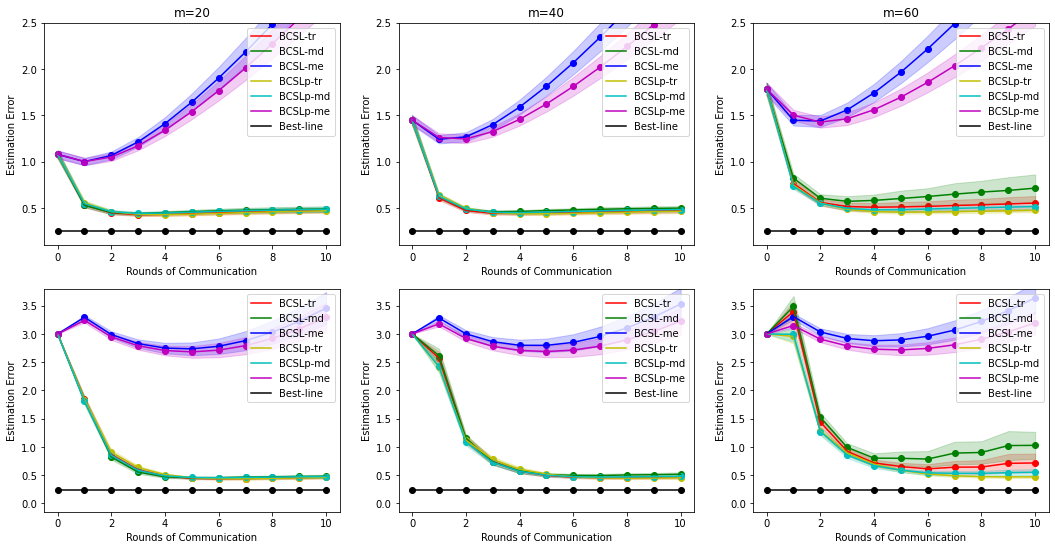

In [17]:
fig = plt.figure(figsize=(18,9))
a = 1
for isgood in [True,False]:
    for m in [20,40,60]:
        plt.subplot(230+a)
        a += 1
        avg_best_error,avg_error = read_data(u=u,isgood=isgood,m=m)[:2]
        present(avg_best_error,*avg_error)
        plt.ylabel('Estimation Error')
        if a < 5:
            plt.title('m='+str(m))
            plt.ylim([0.1,2.5])
            
plt.show(fig)
##复制

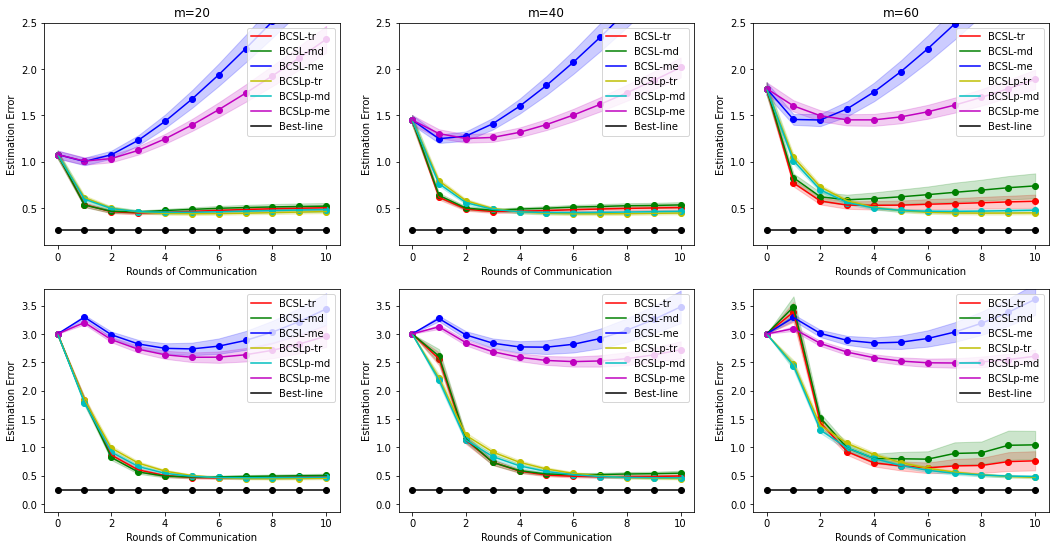

In [19]:
fig = plt.figure(figsize=(18,9))
a = 1
for isgood in [True,False]:
    for m in [20,40,60]:
        plt.subplot(230+a)
        a += 1
        avg_best_error,avg_error = read_data(u=u,isgood=isgood,m=m)[:2]
        present(avg_best_error,*avg_error)
        plt.ylabel('Estimation Error')
        if a < 5:
            plt.title('m='+str(m))
            plt.ylim([0.1,2.5])
            
plt.show(fig)

In [15]:
def sheet(m,isgood):
    error = np.load(file='./exp_data/error_m{}-{}-{}.npy'.format(m,init_name(isgood),norm_name(u)))
    best_error = np.load('./exp_data/best_error_m{}-{}-{}.npy'.format(m,init_name(isgood),norm_name(u)))
    sheet = np.concatenate((error.mean(0)[:,9],[best_error.mean()]))
    return sheet

st = []
for j in [True,False]:
    for i in [20,40,60]:

        st.append(sheet(i,j))
st = pd.DataFrame(st,columns=['no_bad(a)','mean(a)','trimean(a)','median(a)','trimean','median','no_bad','mean','best_line'],
                  index=['m=20,goodinit','m=40,goodinit','m=60,goodinit','m=20,zeroinit','m=40,zeroinit','m=60,zeroinit'])
st.to_csv('./exp1.csv')